In [12]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [1]:
import dataiku
from dataiku import pandasutils as pdu
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

In [0]:
# Example: load a DSS dataset as a Pandas dataframe
# import dataiku
# mydataset = dataiku.Dataset("mydataset")
# mydataset_df = mydataset.get_dataframe()

In [2]:
# data= pd.read_csv('')



scaler = StandardScaler()
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(random_state=42))])
# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svc', LinearSVC(random_state=42))
# ])


# svm_model = SVC(kernel='linear', C=1.0, random_state=42)
# svm_model.fit(scaler.fit_transform(X_train), (y_train))
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)

# y_pred = svm_model.predict(scaler.fit_transform(X_test))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.9766081871345029

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97        63
           1       0.99      0.97      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



/home/dataiku/dss_data/code-envs/python/my-venv/lib/python3.7/site-packages/ipykernel/pylab/backend_inline.py:156: DeprecationWarning: `configure_inline_support` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.configure_inline_support()`
  configure_inline_support(ip, backend)


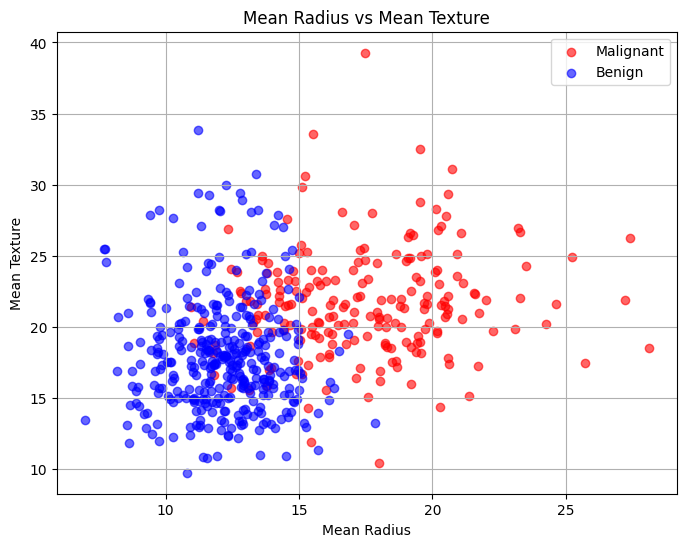

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
# print(df)
plt.figure(figsize=(8, 6))
for target, color, label in zip([0, 1], ['red', 'blue'], ['Malignant', 'Benign']):
    subset = df[df['target'] == target]
    plt.scatter(subset['mean radius'], subset['mean texture'], c=color, label=label, alpha=0.6)
plt.title('Mean Radius vs Mean Texture')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
parameters = {'kernel': ('linear', 'rbf'), 'C': [1, 10]}
svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(data.data, data.target)
print(f"Best parameters: {clf.best_params_}")
print(f"Best score: {clf.best_score_}")

Best parameters: {'C': 10, 'kernel': 'linear'}
Best score: 0.9525694767893185


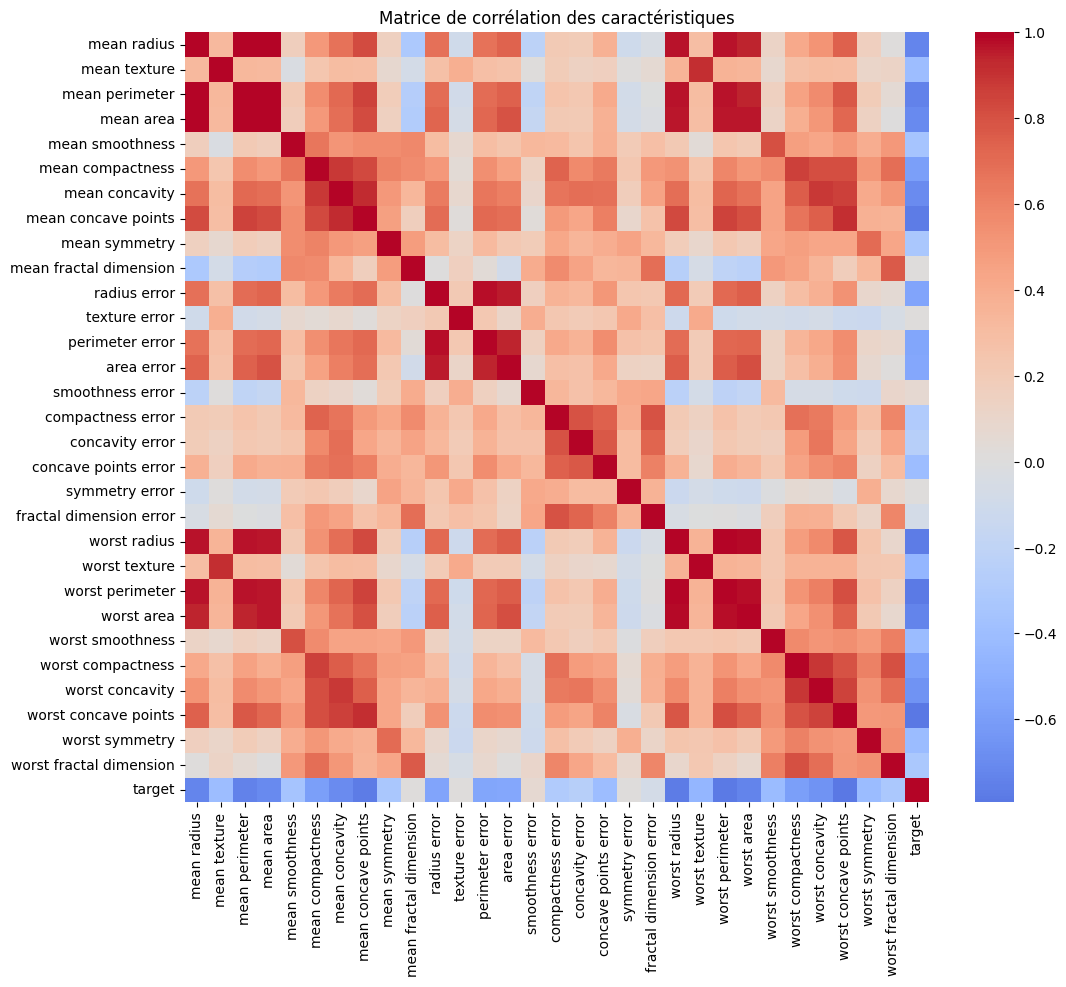

In [5]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des caractéristiques')
plt.show()


/home/dataiku/dss_data/code-envs/python/my-venv/lib/python3.7/site-packages/pkg_resources/__init__.py:2804: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)


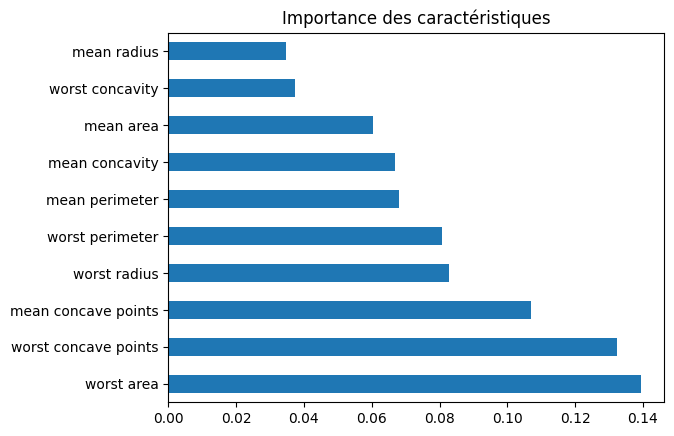

In [6]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(data.data, data.target)
importances = pd.Series(model.feature_importances_, index=data.feature_names)
importances.nlargest(10).plot(kind='barh')
plt.title('Importance des caractéristiques')
plt.show()
  